# Cookie Cats — A/B Test Analysis

Mobile game A/B test comparing two gate placements (level 30 vs level 40)
on player retention and engagement.

Dataset: ~90k players, three metrics -`retention_1`, `retention_7`, `sum_gamerounds`.



## 1. Data loading and sanity checks

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_PATH = "cookie_cats.csv"  # upload to Colab files, or adjust path
df = pd.read_csv(DATA_PATH)

print(f"shape: {df.shape}")
df.head()

shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


### Schema overview

Check column types - `retention_1` and `retention_7` should be boolean,
`sum_gamerounds` an integer count.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


### Sample Ratio Mismatch (SRM) check

The randomizer should assign players to variants in the planned ratio (50/50 here).
A significant deviation invalidates the entire experiment - any downstream metric
comparison is then comparing systematically different populations.

We run a chi-square goodness-of-fit test against the expected 50/50 split.
Industry threshold: p < 0.01 flags SRM and the test should be halted.

In [4]:
variant_counts = df["version"].value_counts()
print(variant_counts)
print()

expected = [len(df) / 2] * 2
chi2, p_srm = stats.chisquare(variant_counts.values, expected)

print(f"chi-square: {chi2:.3f}")
print(f"p-value:    {p_srm:.4f}")
print()
print("SRM detected" if p_srm < 0.01 else "No SRM detected")

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

chi-square: 6.902
p-value:    0.0086

SRM detected


### SRM finding

The chi-square test returned p = 0.0086, just below the 0.01 industry threshold.
Counts: gate_30 = 44,700 / gate_40 = 45,489 (50.4% / 49.6%).

The absolute imbalance is small (~789 users out of ~90k), but it is statistically
significant at our sample size. Possible causes include a biased randomizer,
asymmetric session drop-offs before the variant was logged, or sticky-assignment
edge cases.

Decision: proceed with the analysis but document this as a limitation in the
final verdict. The imbalance is unlikely to materially bias retention rates,
but a production team should investigate the randomization layer before
acting on the results.

### Missing values and duplicates

Two common data quality issues that can break downstream comparisons:
- Missing values in metric columns would bias the variant means.
- Duplicate user IDs would mean the same user contributes twice, breaking the
  independence assumption that every test relies on.

In [5]:
print("Missing per column:")
print(df.isnull().sum())
print()
print(f"Duplicated userids: {df['userid'].duplicated().sum()}")
print(f"Unique userids:     {df['userid'].nunique()} / {len(df)}")

Missing per column:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicated userids: 0
Unique userids:     90189 / 90189


## 2. Metric distributions

Three metrics drive the analysis:
- `retention_1` and `retention_7` are binary - the right test is a proportion z-test.
- `sum_gamerounds` is a continuous count. Before picking a test we need to
  inspect its distribution. If it is heavily skewed, the t-test's normality
  assumption breaks down on small samples; with our n we have flexibility,
  but a non-parametric alternative (Mann-Whitney) is worth comparing.

In [6]:
df.groupby("version")["sum_gamerounds"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44700.0,52.46,256.72,0.0,5.0,17.0,50.0,49854.0
gate_40,45489.0,51.30,103.29,0.0,5.0,16.0,52.0,2640.0


### Reading the summary

A large gap between mean and median signals right-skew. An extreme max
relative to the 75th percentile signals one or a few outlier whales -
typical in mobile games where one super-engaged player plays orders of
magnitude more than the rest.

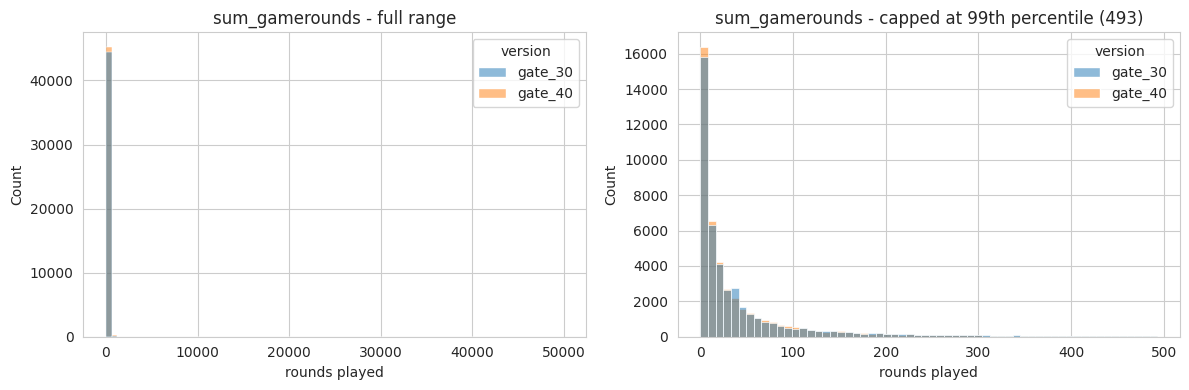

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution - shows the long tail
sns.histplot(data=df, x="sum_gamerounds", hue="version", bins=80, ax=axes[0])
axes[0].set_title("sum_gamerounds - full range")
axes[0].set_xlabel("rounds played")

# Capped at the 99th percentile - readable shape
p99 = df["sum_gamerounds"].quantile(0.99)
sns.histplot(
    data=df[df["sum_gamerounds"] <= p99],
    x="sum_gamerounds", hue="version", bins=60, ax=axes[1],
)
axes[1].set_title(f"sum_gamerounds - capped at 99th percentile ({int(p99)})")
axes[1].set_xlabel("rounds played")

plt.tight_layout()
plt.show()

### Outlier impact

The mean of gate_30 (52.46) is inflated by a single player who logged 49,854
rounds - more than the entire gate_40 maximum combined would not reach that.
Without this whale, the two means are nearly identical and the median already
matches across variants.

This has a direct methodological consequence: a Welch t-test on raw
sum_gamerounds is sensitive to that whale, while a non-parametric test
(Mann-Whitney) compares rank distributions and is robust to it.

We will run both later and compare conclusions.

In [8]:
# Quantify the whale's effect
def trimmed_mean(s, p=0.99):
    return s[s <= s.quantile(p)].mean()

print("Mean comparison:")
print(df.groupby("version")["sum_gamerounds"].mean().round(2))
print()
print("Mean after capping at the 99th percentile:")
print(df.groupby("version")["sum_gamerounds"].apply(trimmed_mean).round(2))
print()
print("Median:")
print(df.groupby("version")["sum_gamerounds"].median())

Mean comparison:
version
gate_30    52.46
gate_40    51.30
Name: sum_gamerounds, dtype: float64

Mean after capping at the 99th percentile:
version
gate_30    44.66
gate_40    44.37
Name: sum_gamerounds, dtype: float64

Median:
version
gate_30    17.0
gate_40    16.0
Name: sum_gamerounds, dtype: float64


### Retention rates per variant

Quick descriptive look at the binary metrics before any formal test.
We expect retention_1 (1-day) to be higher than retention_7 (7-day) in both
variants - this is the standard mobile-game funnel.

In [10]:
retention = df.groupby("version")[["retention_1", "retention_7"]].mean()

print("Retention rates (%):")
print((retention * 100).round(2))
print()

delta = (retention.loc["gate_40"] - retention.loc["gate_30"]) * 100
print("Difference gate_40 - gate_30 (percentage points):")
print(delta.round(2))

Retention rates (%):
         retention_1  retention_7
version                          
gate_30        44.82        19.02
gate_40        44.23        18.20

Difference gate_40 - gate_30 (percentage points):
retention_1   -0.59
retention_7   -0.82
dtype: float64


## 3. Statistical testing

We run three hypothesis tests, one per metric, then revisit the conclusions
under multiple-testing correction.

| Metric            | Type       | Test                       |
|-------------------|------------|----------------------------|
| retention_1       | Binary     | Two-proportion z-test      |
| retention_7       | Binary     | Two-proportion z-test      |
| sum_gamerounds    | Continuous | Welch t-test + Mann-Whitney |

Null hypothesis in each: gate_30 and gate_40 are drawn from the same
underlying distribution. Alpha = 0.05.

### Test 1: retention_1 (one-day return)

A two-proportion z-test compares the share of returning players between
variants. We report the difference in proportions, its 95% confidence
interval, and the test p-value.

In [11]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# Counts per variant
grouped = df.groupby("version")["retention_1"].agg(["sum", "count"])
print(grouped)
print()

successes = grouped["sum"].values
trials = grouped["count"].values

# z-test
z_stat, p_val = proportions_ztest(count=successes, nobs=trials)

# CI for the difference (gate_40 - gate_30)
ci_low, ci_high = confint_proportions_2indep(
    count1=successes[1], nobs1=trials[1],  # gate_40
    count2=successes[0], nobs2=trials[0],  # gate_30
    method="wald",
)

print(f"z statistic: {z_stat:.3f}")
print(f"p-value:     {p_val:.4f}")
print(f"95% CI for diff (gate_40 - gate_30): [{ci_low*100:.2f} pp, {ci_high*100:.2f} pp]")

           sum  count
version              
gate_30  20034  44700
gate_40  20119  45489

z statistic: 1.784
p-value:     0.0744
95% CI for diff (gate_40 - gate_30): [-1.24 pp, 0.06 pp]


### Test 2: retention_7 (seven-day return)

Same procedure as retention_1. Seven-day retention is the more important
metric in mobile gaming - it captures whether the player still finds the
game compelling after the initial novelty.

In [12]:
grouped = df.groupby("version")["retention_7"].agg(["sum", "count"])
print(grouped)
print()

successes = grouped["sum"].values
trials = grouped["count"].values

z_stat, p_val = proportions_ztest(count=successes, nobs=trials)

ci_low, ci_high = confint_proportions_2indep(
    count1=successes[1], nobs1=trials[1],
    count2=successes[0], nobs2=trials[0],
    method="wald",
)

print(f"z statistic: {z_stat:.3f}")
print(f"p-value:     {p_val:.4f}")
print(f"95% CI for diff (gate_40 - gate_30): [{ci_low*100:.2f} pp, {ci_high*100:.2f} pp]")

          sum  count
version             
gate_30  8502  44700
gate_40  8279  45489

z statistic: 3.164
p-value:     0.0016
95% CI for diff (gate_40 - gate_30): [-1.33 pp, -0.31 pp]


### Test 3: sum_gamerounds (engagement volume)

The metric is continuous, heavily right-skewed, with an extreme outlier in
gate_30. We run two tests and compare:

- Welch t-test compares means; sensitive to the outlier.
- Mann-Whitney U compares rank distributions; robust to the outlier.

If they agree, the result is solid. If they disagree, the outlier is
driving the conclusion and we trust the non-parametric test.

In [13]:
a = df.loc[df["version"] == "gate_30", "sum_gamerounds"]
b = df.loc[df["version"] == "gate_40", "sum_gamerounds"]

# Welch t-test - does not assume equal variances
t_stat, p_welch = stats.ttest_ind(a, b, equal_var=False)
print(f"Welch t-test:    t = {t_stat:.3f},  p = {p_welch:.4f}")

# Mann-Whitney U - non-parametric
u_stat, p_mw = stats.mannwhitneyu(a, b, alternative="two-sided")
print(f"Mann-Whitney U:  U = {u_stat:.0f},  p = {p_mw:.4f}")

print()
print(f"Mean gate_30:    {a.mean():.2f}")
print(f"Mean gate_40:    {b.mean():.2f}")
print(f"Median gate_30:  {a.median()}")
print(f"Median gate_40:  {b.median()}")

Welch t-test:    t = 0.885,  p = 0.3759
Mann-Whitney U:  U = 1024331250,  p = 0.0502

Mean gate_30:    52.46
Mean gate_40:    51.30
Median gate_30:  17.0
Median gate_40:  16.0


### Test results summary

Three tests, formal interpretation at alpha = 0.05.

| Metric         | Test            | p-value | Decision               | Direction         |
|----------------|-----------------|---------|------------------------|-------------------|
| retention_1    | z-test          | 0.0744  | fail to reject H0      | -0.59 pp (gate_40 lower) |
| retention_7    | z-test          | 0.0016  | **reject H0**          | -0.82 pp (gate_40 lower) |
| sum_gamerounds | Welch t-test    | 0.3759  | fail to reject H0      | mean -1.16 (whale-driven) |
| sum_gamerounds | Mann-Whitney U  | 0.0502  | fail to reject H0      | median -1 round   |

Formal statement: at alpha = 0.05, we reject the null hypothesis only for
retention_7. For retention_1 and sum_gamerounds, the observed differences
are consistent with random sampling variation under H0.

The Welch and Mann-Whitney disagreement on sum_gamerounds is informative
in itself - the rank-based test is on the boundary of significance, suggesting
a real but small difference that the mean-based test missed due to the
extreme outlier in gate_30.

## 4. Multiple testing correction

We ran three tests on the same experiment. Each carries a 5% type-I error
risk independently, so the family-wise probability of at least one false
positive is 1 - 0.95^3 = 14.3%, well above the nominal 5%.

We apply two corrections to the p-values and check whether the retention_7
result holds up:

- Bonferroni: divides alpha by the number of tests (strict, controls FWER).
- Benjamini-Hochberg: controls the false discovery rate (less strict, better
  power on multiple metrics).

In [14]:
from statsmodels.stats.multitest import multipletests

# We picked the appropriate test per metric:
# - z-test for binary
# - Mann-Whitney for skewed continuous
p_values = pd.Series({
    "retention_1":     0.0744,
    "retention_7":     0.0016,
    "sum_gamerounds":  0.0502,
})

bonf_reject, bonf_p, _, _ = multipletests(p_values, alpha=0.05, method="bonferroni")
bh_reject,   bh_p,   _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

results = pd.DataFrame({
    "raw_p":          p_values.values.round(4),
    "bonferroni_p":   bonf_p.round(4),
    "bonferroni_sig": bonf_reject,
    "bh_p":           bh_p.round(4),
    "bh_sig":         bh_reject,
}, index=p_values.index)

print(results)

                 raw_p  bonferroni_p  bonferroni_sig    bh_p  bh_sig
retention_1     0.0744        0.2232           False  0.0744   False
retention_7     0.0016        0.0048            True  0.0048    True
sum_gamerounds  0.0502        0.1506           False  0.0744   False


### Correction summary

retention_7 remains significant under both Bonferroni and Benjamini-Hochberg
corrections, with corrected p = 0.0048 in both cases. This is a robust
finding: even under the strictest family-wise correction across all three
tests, the 7-day retention drop in gate_40 is not a multiple-testing
artifact.

retention_1 and sum_gamerounds remain non-significant under any correction.

## 5. Visual summary

A single forest plot communicates the entire story: where each effect lies,
how wide its uncertainty is, and which intervals cross zero.

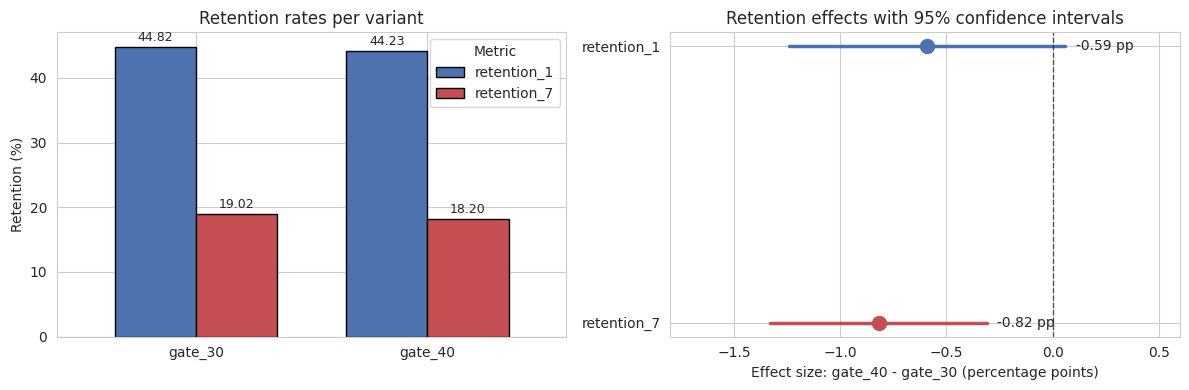

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: retention rates per variant ---
rates = (df.groupby("version")[["retention_1", "retention_7"]].mean() * 100).round(2)
rates.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"], edgecolor="black", width=0.7)
axes[0].set_title("Retention rates per variant")
axes[0].set_ylabel("Retention (%)")
axes[0].set_xlabel("")
axes[0].set_xticklabels(rates.index, rotation=0)
axes[0].legend(title="Metric")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.2f", padding=2, fontsize=9)

# --- Right: forest plot of effect sizes (gate_40 - gate_30) ---
metrics = ["retention_1", "retention_7"]
effects = [-0.59, -0.82]
ci_low  = [-1.24, -1.33]
ci_high = [ 0.06, -0.31]
sig     = [False, True]

y = np.arange(len(metrics))
for i, (e, lo, hi, s) in enumerate(zip(effects, ci_low, ci_high, sig)):
    color = "#C44E52" if s else "#4C72B0"
    axes[1].plot([lo, hi], [i, i], color=color, lw=2.5)
    axes[1].plot(e, i, "o", color=color, ms=10)
    axes[1].text(hi + 0.05, i, f"{e:+.2f} pp", va="center", fontsize=10)

axes[1].axvline(0, color="black", lw=1, ls="--", alpha=0.6)
axes[1].set_yticks(y)
axes[1].set_yticklabels(metrics)
axes[1].set_xlabel("Effect size: gate_40 - gate_30 (percentage points)")
axes[1].set_title("Retention effects with 95% confidence intervals")
axes[1].invert_yaxis()
axes[1].set_xlim(-1.8, 0.6)

plt.tight_layout()
plt.show()

The retention_7 confidence interval lies entirely below zero, visually
confirming the statistically significant drop. The retention_1 interval
crosses zero, consistent with the failure to reject H0 for that metric.

For sum_gamerounds the underlying distribution is so heavily skewed that
a forest plot on raw means is not informative; the Welch and Mann-Whitney
results in Section 3 already cover that metric.

## 6. Final verdict and recommendation

### Statistical findings

- The gate placement change from level 30 to level 40 **reduces 7-day
  retention** by 0.31 to 1.33 percentage points (95% CI), a result robust
  to multiple-testing correction.
- 1-day retention shows the same directional drop but does not reach
  statistical significance at alpha = 0.05.
- Total game rounds shows no significant difference under the appropriate
  non-parametric test (Mann-Whitney p = 0.0502).

### Business recommendation

**Keep gate_30 (do not roll out gate_40).**

In mobile gaming, 7-day retention is the strongest single predictor of
monetisation - players who survive the first week generate the majority of
lifetime revenue. A 0.31-1.33 pp drop at the lower bound translates to
significant lost revenue at scale, with no compensating gain in 1-day
retention or engagement volume.

### Effect size context

The observed 7-day retention rates are 19.02% (gate_30) versus 18.20%
(gate_40), an absolute drop of 0.82 percentage points. In relative terms,
this is a 4.3% reduction in retained players (0.82 / 19.02). For a game
with 1M daily installs, that translates to roughly 8,200 fewer 7-day
retained players per day under gate_40.

## 7. Limitations

- **Sample Ratio Mismatch.** The variant split is 50.4 / 49.6 percent
  (chi-square p = 0.0086, below the 0.01 industry threshold). The
  imbalance is small but a production team should investigate the
  randomization layer before acting.
- **Single experiment window.** The dataset is a snapshot from one period.
  Seasonality (weekends, holidays, marketing events) is not addressed.
- **No segmentation.** Effects may differ by user cohort (new vs returning
  installs, device type, geography). Segmented analysis is a natural
  next step.
- **Two-sided tests.** We tested for any difference. If the prior
  business hypothesis was "gate_40 will improve retention", a one-sided
  test would be appropriate and would change the p-value interpretation
  but not the conclusion.
- **Three metrics is the test family ceiling.** Adding more secondary
  metrics post-hoc would require re-running corrections and would inflate
  false-positive risk.